In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Rescale and Show The Image

Image shape: (682, 1024, 3)


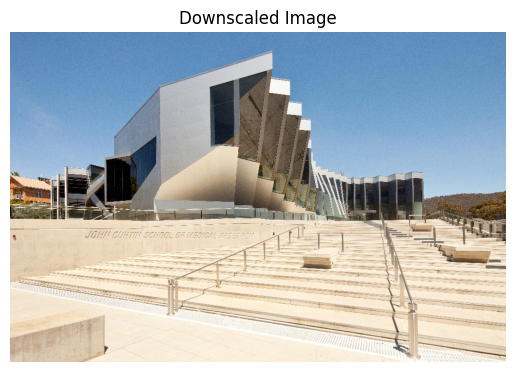

In [20]:
image = cv2.imread('image_data.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

image = cv2.resize(image, (1024, 682))

print(f"Image shape: {image.shape}")

plt.imshow(image)
plt.title("Downscaled Image")
plt.axis('off')
plt.show()

## Extract Patches

In [21]:
def extract_patches(image, patch_size=64, stride=32):
    patches = []
    positions = []
    
    h, w, _ = image.shape
    
    for y in range(0, h - patch_size, stride):
        for x in range(0, w - patch_size, stride):
            patch = image[y:y+patch_size, x:x+patch_size]
            patches.append(patch)
            positions.append((y, x))
    
    return patches, positions

Total patches extracted: 600


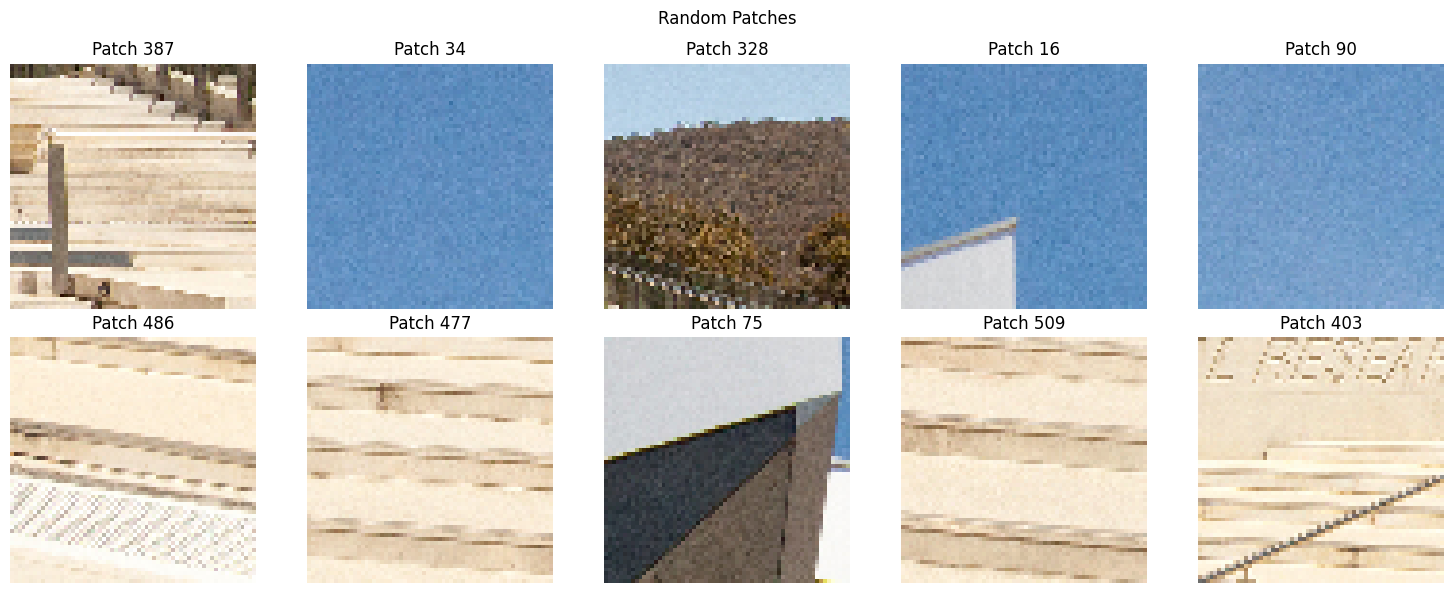

In [22]:
patches, positions = extract_patches(image)
print(f"Total patches extracted: {len(patches)}")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

import random
random_indices = random.sample(range(len(patches)), 10)

for i, idx in enumerate(random_indices):
    axes[i].imshow(patches[idx])
    axes[i].set_title(f"Patch {idx}")
    axes[i].axis('off')

plt.suptitle("Random Patches")
plt.tight_layout()
plt.show()

## Compute Autocorrelation

In [23]:
def compute_autocorrelation(patch):
    gray = cv2.cvtColor(patch, cv2.COLOR_RGB2GRAY).astype(np.float32)
    
    gray = gray - gray.mean()
    if gray.std() > 0:
        gray = gray / gray.std()
    
    f = np.fft.fft2(gray)
    power = np.abs(f) ** 2
    autocorr = np.fft.ifft2(power).real
    autocorr = np.fft.fftshift(autocorr)
    
    h, w = autocorr.shape
    center_y, center_x = h // 2, w // 2
    autocorr = autocorr / autocorr[center_y, center_x]
    
    mask_radius = 3
    autocorr_masked = autocorr.copy()
    autocorr_masked[center_y-mask_radius:center_y+mask_radius+1, 
                    center_x-mask_radius:center_x+mask_radius+1] = 0
    
    score = autocorr_masked.max()
    return score

Min score: 0.080
Max score: 0.993
Mean score: 0.598


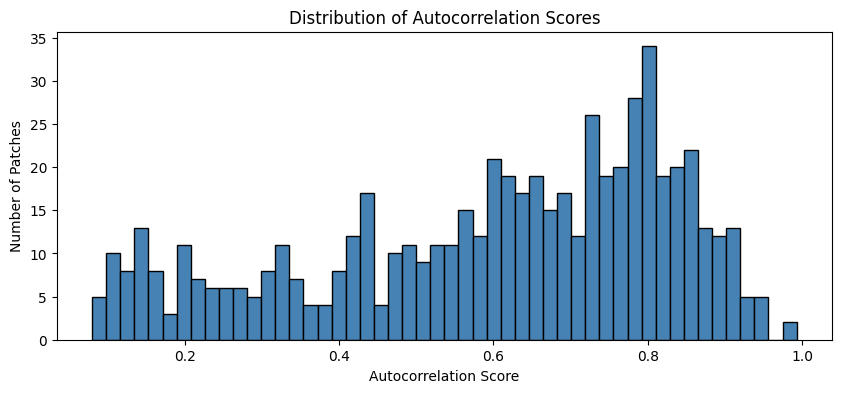

In [24]:
scores = [compute_autocorrelation(p) for p in patches]
scores = np.array(scores)

print(f"Min score: {scores.min():.3f}")
print(f"Max score: {scores.max():.3f}")
print(f"Mean score: {scores.mean():.3f}")

plt.figure(figsize=(10, 4))
plt.hist(scores, bins=50, color='steelblue', edgecolor='black')
plt.xlabel("Autocorrelation Score")
plt.ylabel("Number of Patches")
plt.title("Distribution of Autocorrelation Scores")
plt.show()

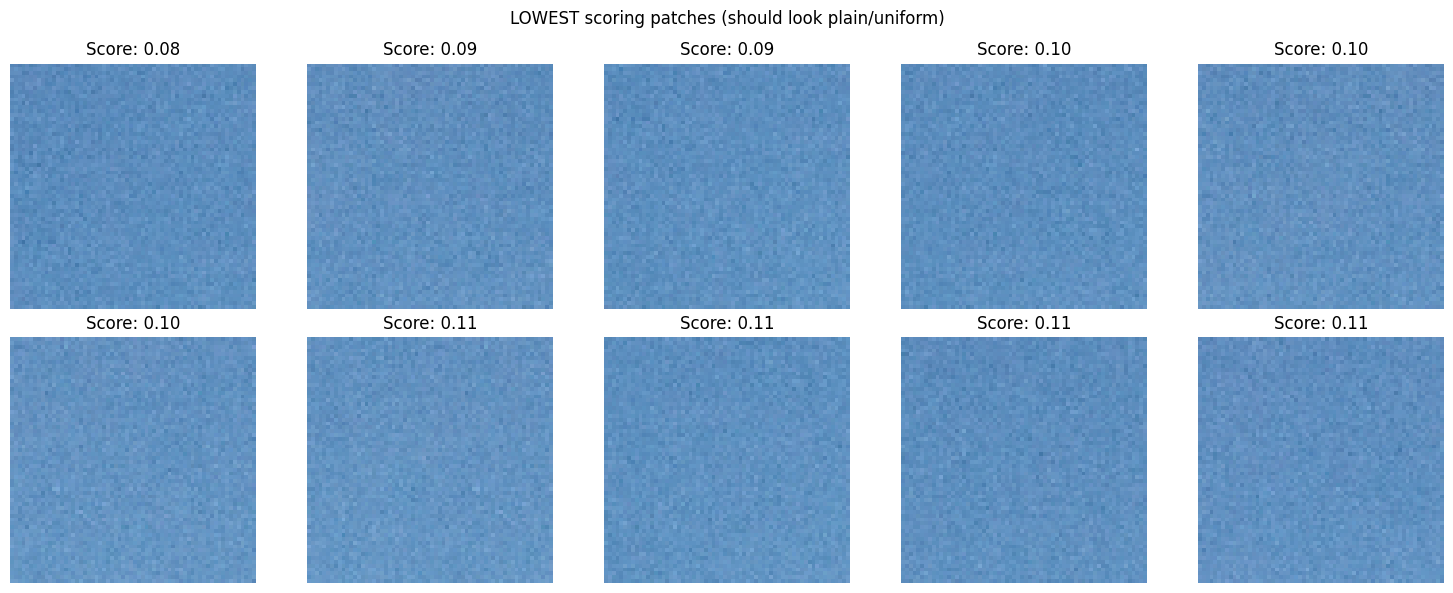

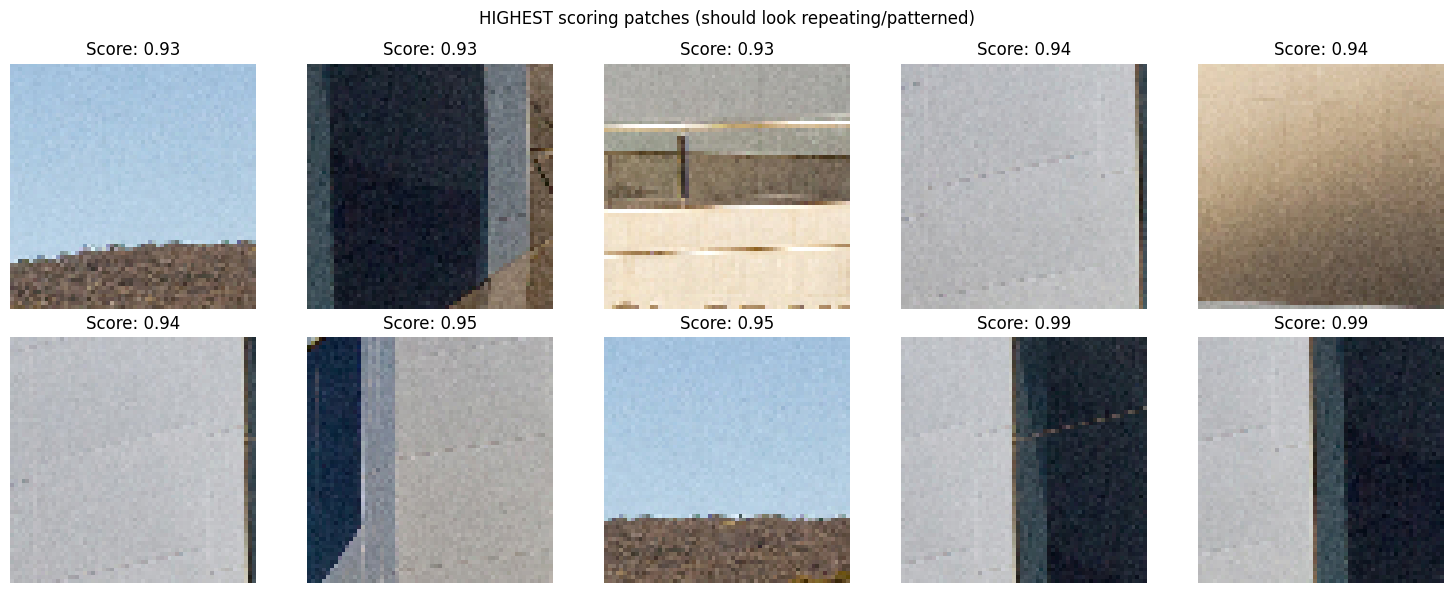

In [25]:
# Sort patches by score
sorted_indices = np.argsort(scores)

# Show 10 lowest scoring patches (should be smooth/uniform)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for i, idx in enumerate(sorted_indices[:10]):
    axes[i].imshow(patches[idx])
    axes[i].set_title(f"Score: {scores[idx]:.2f}")
    axes[i].axis('off')
plt.suptitle("LOWEST scoring patches (should look plain/uniform)")
plt.tight_layout()
plt.show()

# Show 10 highest scoring patches (should be repeating)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for i, idx in enumerate(sorted_indices[-10:]):
    axes[i].imshow(patches[idx])
    axes[i].set_title(f"Score: {scores[idx]:.2f}")
    axes[i].axis('off')
plt.suptitle("HIGHEST scoring patches (should look repeating/patterned)")
plt.tight_layout()
plt.show()

## Labelling the Patches Based on the Scores

Threshold (median): 0.647
Total patches: 600
YES (repeating): 300
NO (not repeating): 300


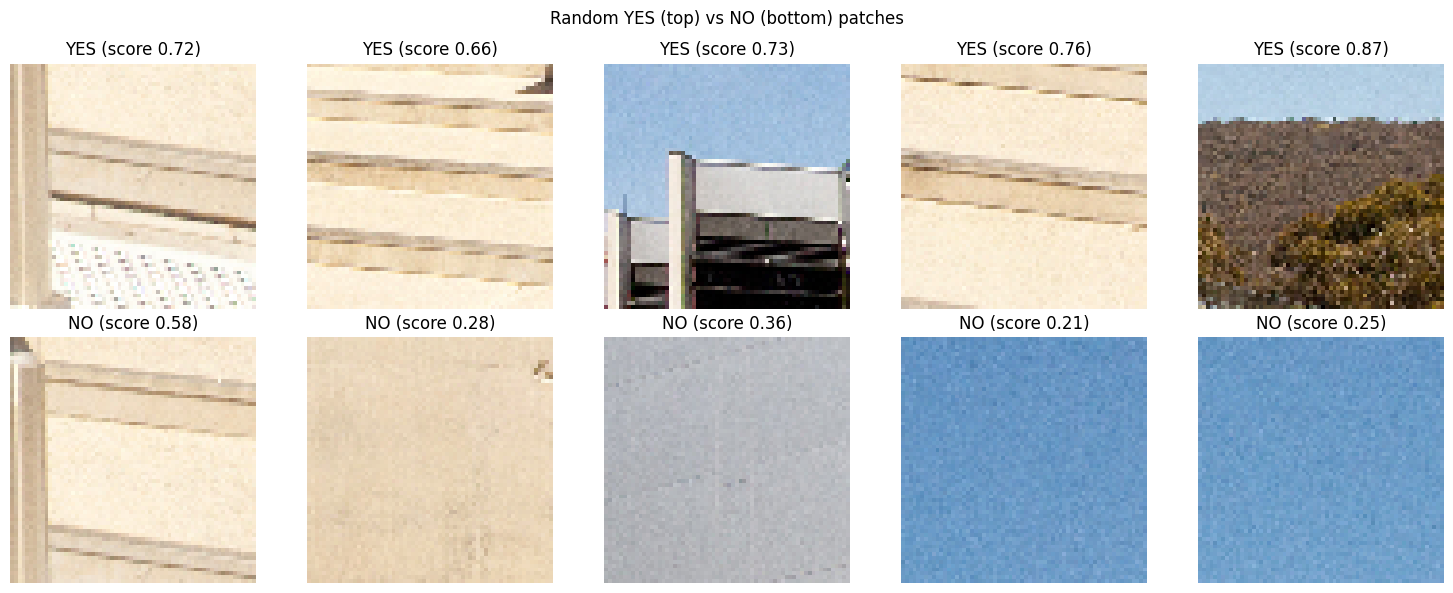

In [26]:
# Convert scores to binary labels using a threshold
# Threshold = median means roughly half are YES and half are NO
threshold = np.median(scores)
print(f"Threshold (median): {threshold:.3f}")

labels = (scores > threshold).astype(int)

print(f"Total patches: {len(labels)}")
print(f"YES (repeating): {labels.sum()}")
print(f"NO (not repeating): {len(labels) - labels.sum()}")

# Visualize sample labelled patches
import random

# Show 5 YES and 5 NO patches
yes_indices = np.where(labels == 1)[0]
no_indices = np.where(labels == 0)[0]

random_yes = random.sample(list(yes_indices), 5)
random_no = random.sample(list(no_indices), 5)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, idx in enumerate(random_yes):
    axes[0, i].imshow(patches[idx])
    axes[0, i].set_title(f"YES (score {scores[idx]:.2f})")
    axes[0, i].axis('off')

for i, idx in enumerate(random_no):
    axes[1, i].imshow(patches[idx])
    axes[1, i].set_title(f"NO (score {scores[idx]:.2f})")
    axes[1, i].axis('off')

plt.suptitle("Random YES (top) vs NO (bottom) patches")
plt.tight_layout()
plt.show()

# Training the Model

In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

## Splitting the data

In [28]:

patches_array = np.array(patches)
print(f"Patches array shape: {patches_array.shape}")

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    patches_array, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Train: {len(X_train)} patches")
print(f"Test: {len(X_test)} patches")
print(f"Train YES: {y_train.sum()}, Train NO: {len(y_train) - y_train.sum()}")
print(f"Test YES: {y_test.sum()}, Test NO: {len(y_test) - y_test.sum()}")

Patches array shape: (600, 64, 64, 3)
Train: 480 patches
Test: 120 patches
Train YES: 240, Train NO: 240
Test YES: 60, Test NO: 60


In [29]:
# Custom Dataset class
class PatchDataset(Dataset):
    def __init__(self, patches, labels, augment=False):
        self.patches = patches
        self.labels = labels
        self.augment = augment
    
    def __len__(self):
        return len(self.patches)
    
    def __getitem__(self, idx):
        patch = self.patches[idx].astype(np.float32) / 255.0  # Normalize to 0-1
        label = self.labels[idx]
        
        # Augmentation (only during training)
        if self.augment:
            # Random horizontal flip
            if random.random() > 0.5:
                patch = np.fliplr(patch).copy()
            # Random vertical flip
            if random.random() > 0.5:
                patch = np.flipud(patch).copy()
            # Random 90 degree rotation
            k = random.randint(0, 3)
            patch = np.rot90(patch, k).copy()
        
        # Convert to tensor: HWC -> CHW
        patch = torch.from_numpy(patch).permute(2, 0, 1)
        return patch, torch.tensor(label, dtype=torch.long)


In [30]:
# Create datasets
train_dataset = PatchDataset(X_train, y_train, augment=True)
test_dataset = PatchDataset(X_test, y_test, augment=False)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

# Test that one batch works
patch_batch, label_batch = next(iter(train_loader))
print(f"Batch shape: {patch_batch.shape}")  # Should be [32, 3, 64, 64]
print(f"Labels shape: {label_batch.shape}")  # Should be [32]

Train batches: 15
Test batches: 4
Batch shape: torch.Size([32, 3, 64, 64])
Labels shape: torch.Size([32])


## Defining the CNN

In [31]:
# Define the CNN
class RepetitionDetector(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)   # 3 -> 32 channels
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # 32 -> 64
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1) # 64 -> 128
        
        self.pool = nn.MaxPool2d(2, 2)  # Halves spatial size
        
        # After 3 pool operations: 64 -> 32 -> 16 -> 8
        # So feature map is 128 channels x 8 x 8 = 8192 features
        self.fc1 = nn.Linear(128 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 2)  # 2 classes: NO and YES
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
    
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))  # [B, 32, 32, 32]
        x = self.pool(self.relu(self.conv2(x)))  # [B, 64, 16, 16]
        x = self.pool(self.relu(self.conv3(x)))  # [B, 128, 8, 8]
        
        x = x.reshape(x.size(0), -1)  # Flatten
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [32]:
# Create model and move to GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = RepetitionDetector().to(device)

# Print model summary
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

# Test forward pass with a dummy batch
dummy_input = torch.randn(2, 3, 64, 64).to(device)
output = model(dummy_input)
print(f"Output shape: {output.shape}")  # Should be [2, 2]

Using device: cuda
Total parameters: 1,142,210
Output shape: torch.Size([2, 2])


Starting training...
------------------------------------------------------------
Epoch  1/30 | Loss: 0.6961 | Train Acc: 63.12% | Test Acc: 71.67%
Epoch  2/30 | Loss: 0.6019 | Train Acc: 68.12% | Test Acc: 71.67%
Epoch  3/30 | Loss: 0.5602 | Train Acc: 71.88% | Test Acc: 70.83%
Epoch  4/30 | Loss: 0.5417 | Train Acc: 72.92% | Test Acc: 70.00%
Epoch  5/30 | Loss: 0.5449 | Train Acc: 72.29% | Test Acc: 71.67%
Epoch  6/30 | Loss: 0.5314 | Train Acc: 71.88% | Test Acc: 70.83%
Epoch  7/30 | Loss: 0.5437 | Train Acc: 72.92% | Test Acc: 72.50%
Epoch  8/30 | Loss: 0.5259 | Train Acc: 72.92% | Test Acc: 74.17%
Epoch  9/30 | Loss: 0.5382 | Train Acc: 72.92% | Test Acc: 73.33%
Epoch 10/30 | Loss: 0.5258 | Train Acc: 73.54% | Test Acc: 74.17%
Epoch 11/30 | Loss: 0.5139 | Train Acc: 73.12% | Test Acc: 73.33%
Epoch 12/30 | Loss: 0.5277 | Train Acc: 73.33% | Test Acc: 75.00%
Epoch 13/30 | Loss: 0.5135 | Train Acc: 70.42% | Test Acc: 72.50%
Epoch 14/30 | Loss: 0.5156 | Train Acc: 73.33% | Test Acc: 7

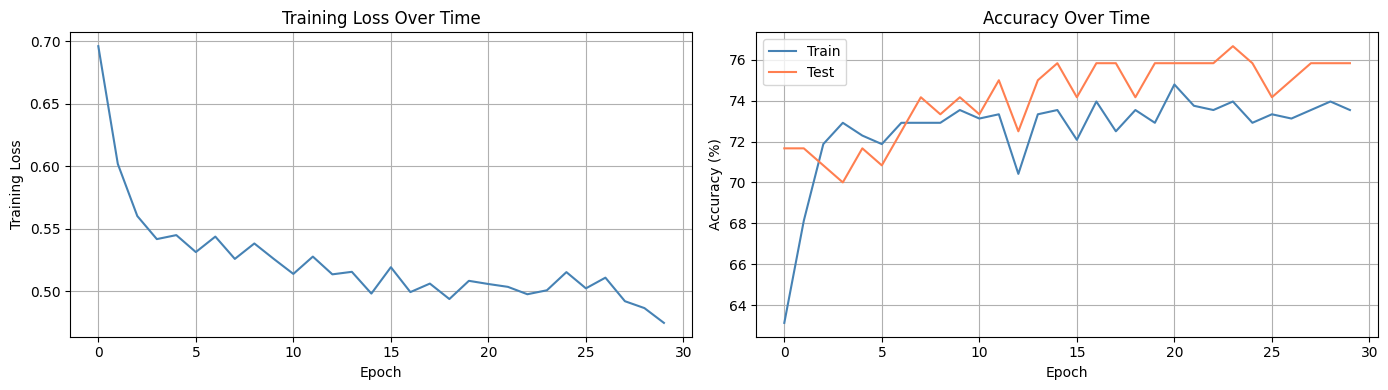

In [33]:
# Training setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Track metrics
train_losses = []
train_accuracies = []
test_accuracies = []

num_epochs = 30

print("Starting training...")
print("-" * 60)

for epoch in range(num_epochs):
    # Training phase
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for patches_batch, labels_batch in train_loader:
        patches_batch = patches_batch.to(device)
        labels_batch = labels_batch.to(device)
        
        # Forward pass
        outputs = model(patches_batch)
        loss = criterion(outputs, labels_batch)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Track metrics
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels_batch.size(0)
        correct += predicted.eq(labels_batch).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    
    # Evaluation phase
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for patches_batch, labels_batch in test_loader:
            patches_batch = patches_batch.to(device)
            labels_batch = labels_batch.to(device)
            outputs = model(patches_batch)
            _, predicted = outputs.max(1)
            total += labels_batch.size(0)
            correct += predicted.eq(labels_batch).sum().item()
    
    test_acc = 100 * correct / total
    test_accuracies.append(test_acc)
    
    print(f"Epoch {epoch+1:2d}/{num_epochs} | Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

print("-" * 60)
print("Training complete!")

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(train_losses, color='steelblue')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Training Loss")
axes[0].set_title("Training Loss Over Time")
axes[0].grid(True)

axes[1].plot(train_accuracies, label='Train', color='steelblue')
axes[1].plot(test_accuracies, label='Test', color='coral')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Accuracy Over Time")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Generating heatmap of size 39x61...
Heatmap shape: (39, 61)
Heatmap range: 0.008 to 0.997


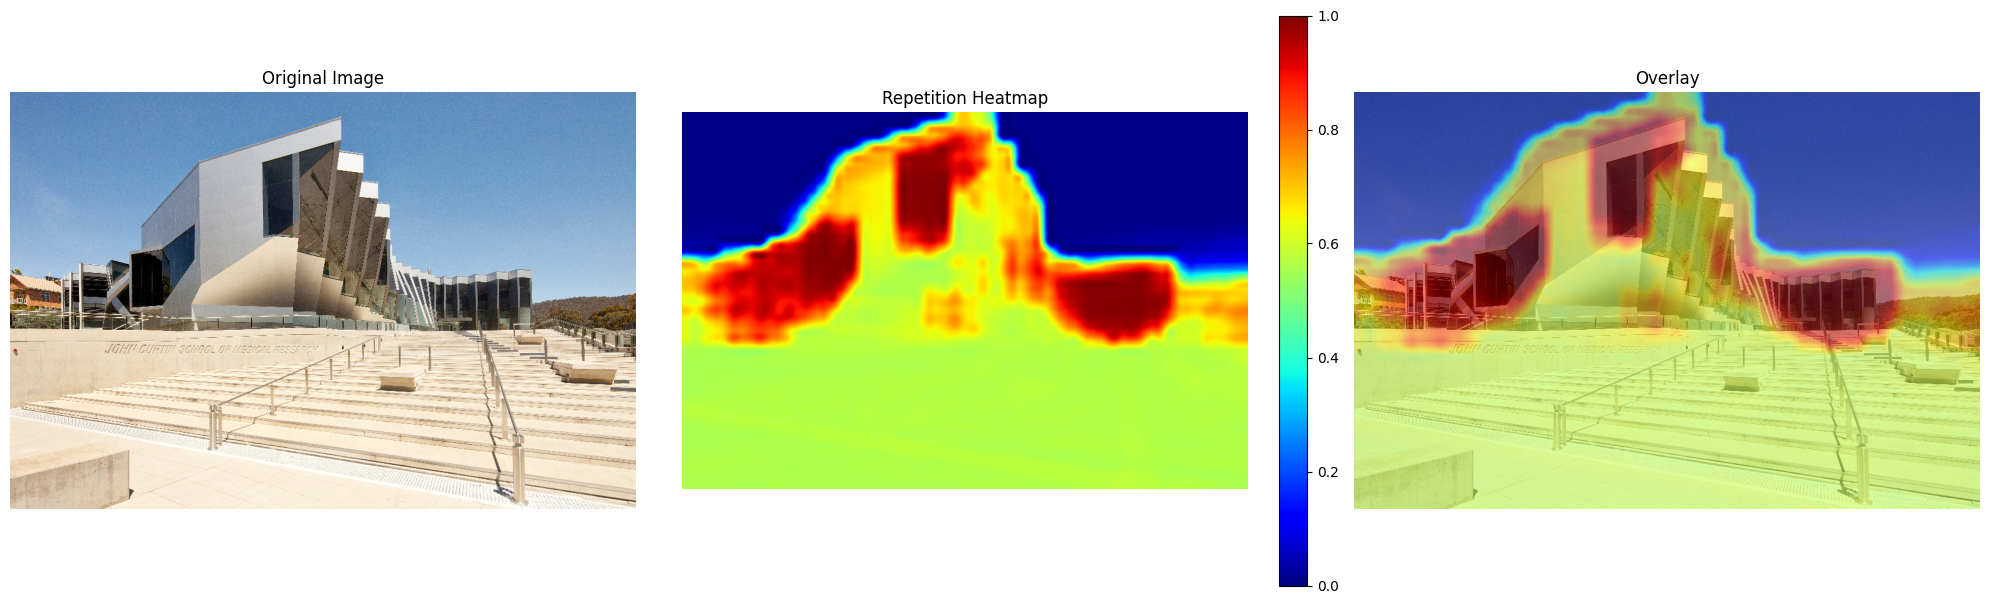

In [34]:
# Generate heatmap by sliding window across the entire image
def generate_heatmap(model, image, patch_size=64, stride=16):
    model.eval()
    
    h, w, _ = image.shape
    
    # Calculate output dimensions
    out_h = (h - patch_size) // stride + 1
    out_w = (w - patch_size) // stride + 1
    
    heatmap = np.zeros((out_h, out_w))
    
    print(f"Generating heatmap of size {out_h}x{out_w}...")
    
    # Collect all patches
    all_patches = []
    positions = []
    for i, y in enumerate(range(0, h - patch_size + 1, stride)):
        for j, x in enumerate(range(0, w - patch_size + 1, stride)):
            patch = image[y:y+patch_size, x:x+patch_size]
            all_patches.append(patch)
            positions.append((i, j))
    
    # Process in batches for speed
    batch_size = 64
    with torch.no_grad():
        for batch_start in range(0, len(all_patches), batch_size):
            batch = all_patches[batch_start:batch_start+batch_size]
            batch_tensor = np.array(batch).astype(np.float32) / 255.0
            batch_tensor = torch.from_numpy(batch_tensor).permute(0, 3, 1, 2).to(device)
            
            outputs = model(batch_tensor)
            probs = torch.softmax(outputs, dim=1)[:, 1]  # Probability of YES (repeating)
            probs = probs.cpu().numpy()
            
            for k, prob in enumerate(probs):
                i, j = positions[batch_start + k]
                heatmap[i, j] = prob
    
    return heatmap

# Generate heatmap
heatmap = generate_heatmap(model, image, patch_size=64, stride=16)
print(f"Heatmap shape: {heatmap.shape}")
print(f"Heatmap range: {heatmap.min():.3f} to {heatmap.max():.3f}")

# Resize heatmap to match image dimensions for overlay
heatmap_resized = cv2.resize(heatmap, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_CUBIC)

# Visualize: original image, heatmap, and overlay
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis('off')

im = axes[1].imshow(heatmap_resized, cmap='jet', vmin=0, vmax=1)
axes[1].set_title("Repetition Heatmap")
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046)

axes[2].imshow(image)
axes[2].imshow(heatmap_resized, cmap='jet', alpha=0.5, vmin=0, vmax=1)
axes[2].set_title("Overlay")
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Saving the heatmap


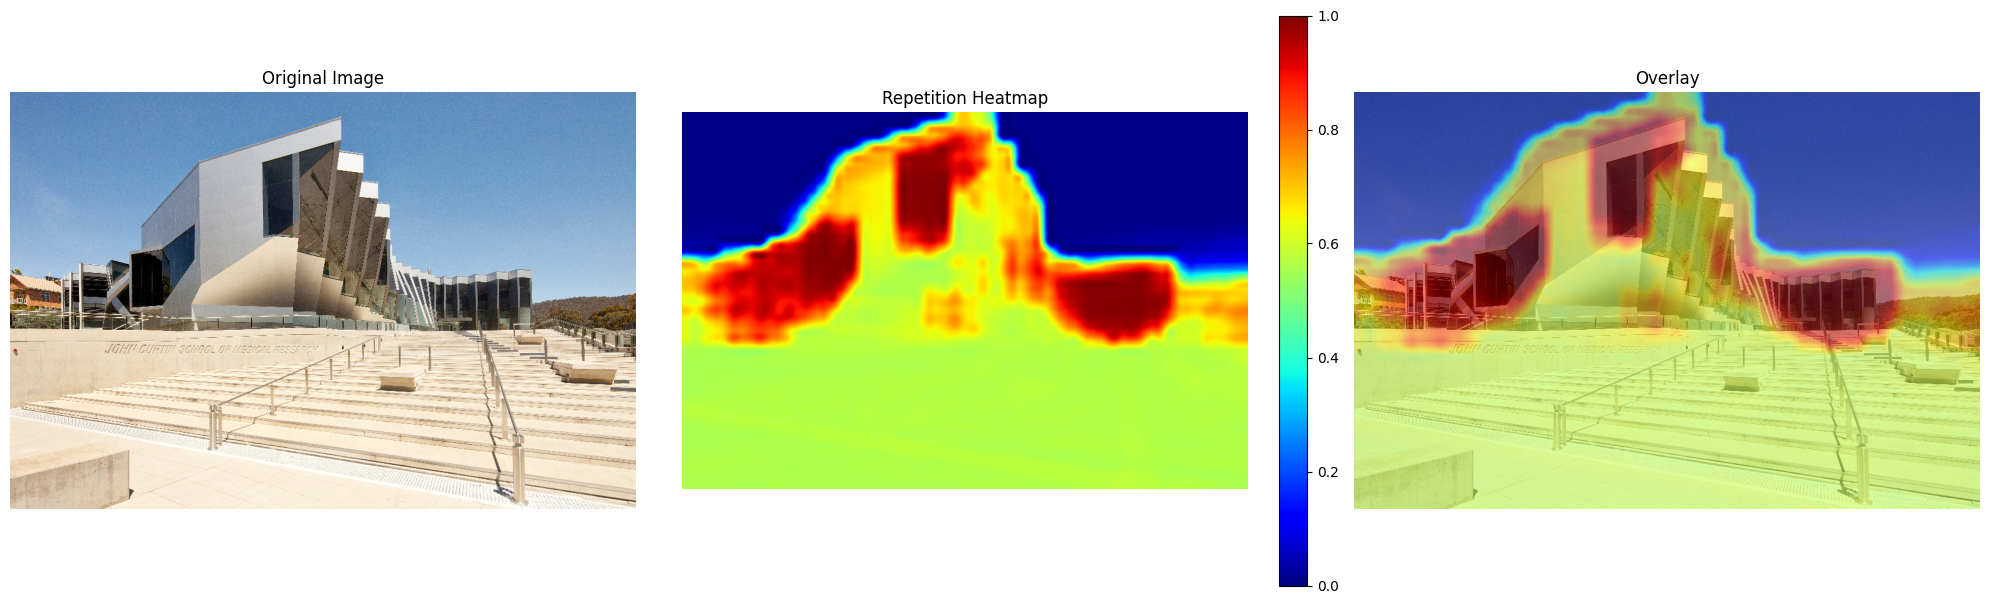

Saved main_heatmap.png


In [35]:
# Save the heatmap figure
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis('off')

im = axes[1].imshow(heatmap_resized, cmap='jet', vmin=0, vmax=1)
axes[1].set_title("Repetition Heatmap")
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046)

axes[2].imshow(image)
axes[2].imshow(heatmap_resized, cmap='jet', alpha=0.5, vmin=0, vmax=1)
axes[2].set_title("Overlay")
axes[2].axis('off')

plt.tight_layout()
plt.savefig('main_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved main_heatmap.png")